In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    make_scorer,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC

%matplotlib inline

In [2]:
df = pd.read_excel(r"C:\Users\GWX-DATA\Videos\Captures\BANK\Lloyds.xlsx")
df

,CustomerID,InteractionID,InteractionDate,InteractionType,ResolutionStatus,TransactionID,TransactionDate,AmountSpent,ProductCategory,Age,AgeBracket,Gender,MaritalStatus,IncomeLevel,LastLoginDate,LoginFrequency,ServiceUsage,ChurnStatus
0,1,6363.0,2022-03-31,Inquiry,Resolved,7194,2022-03-27,416.50,Electronics,62,Elder,M,Single,Low,2023-10-21,34,Mobile App,0
1,2,3329.0,2022-03-17,Inquiry,Resolved,7250,2022-08-08,54.96,Clothing,65,Elder,M,Married,Low,2023-12-05,5,Website,1
2,2,3329.0,2022-03-17,Inquiry,Resolved,9660,2022-07-25,197.50,Electronics,65,Elder,M,Married,Low,2023-12-05,5,Website,1
3,2,3329.0,2022-03-17,Inquiry,Resolved,2998,2022-01-25,101.31,Furniture,65,Elder,M,Married,Low,2023-12-05,5,Website,1
4,2,3329.0,2022-03-17,Inquiry,Resolved,1228,2022-07-24,397.37,Clothing,65,Elder,M,Married,Low,2023-12-05,5,Website,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6807,1000,NaN,NaT,NaN,NaN,2724,2022-09-08,232.06,Groceries,34,Adult,M,Widowed,Low,2023-08-13,22,Mobile App,0
6808,1000,NaN,NaT,NaN,NaN,2917,2022-12-13,324.98,Books,34,Adult,M,Widowed,Low,2023-08-13,22,Mobile App,0
6809,1000,NaN,NaT,NaN,NaN,2979,2022-06-15,375.34,Groceries,34,Adult,M,Widowed,Low,2023-08-13,22,Mobile App,0
6810,1000,NaN,NaT,NaN,NaN,8594,2022-04-08,166.73,Books,34,Adult,M,Widowed,Low,2023-08-13,22,Mobile App,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6812 entries, 0 to 6811
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   CustomerID        6812 non-null   int64         
 1   InteractionID     5204 non-null   float64       
 2   InteractionDate   5204 non-null   datetime64[ns]
 3   InteractionType   5204 non-null   object        
 4   ResolutionStatus  5204 non-null   object        
 5   TransactionID     6812 non-null   int64         
 6   TransactionDate   6812 non-null   datetime64[ns]
 7   AmountSpent       6812 non-null   float64       
 8   ProductCategory   6812 non-null   object        
 9   Age               6812 non-null   int64         
 10  AgeBracket        6812 non-null   object        
 11  Gender            6812 non-null   object        
 12  MaritalStatus     6812 non-null   object        
 13  IncomeLevel       6812 non-null   object        
 14  LastLoginDate     6812 n

In [4]:
df.describe()

,CustomerID,InteractionID,InteractionDate,TransactionID,TransactionDate,AmountSpent,Age,LastLoginDate,LoginFrequency,ChurnStatus
count,6812.000000,5204.000000,5204,6812.000000,6812,6812.000000,6812.000000,6812,6812.000000,6812.000000
mean,500.169260,5921.861261,2022-07-01 16:31:10.561106944,5497.323253,2022-07-01 02:11:29.136817408,251.620527,43.274516,2023-07-06 04:56:47.633587712,25.724310,0.198473
min,1.000000,2015.000000,2022-01-01 00:00:00,1000.000000,2022-01-01 00:00:00,5.180000,18.000000,2023-01-01 00:00:00,1.000000,0.000000
25%,247.000000,3873.250000,2022-04-07 00:00:00,3223.500000,2022-04-02 00:00:00,127.100000,30.000000,2023-04-12 00:00:00,14.000000,0.000000
50%,505.500000,5903.000000,2022-07-02 00:00:00,5515.000000,2022-07-01 00:00:00,251.845000,44.000000,2023-07-13 00:00:00,26.000000,0.000000
75%,750.000000,7851.000000,2022-09-25 00:00:00,7675.250000,2022-09-30 00:00:00,375.280000,56.000000,2023-10-01 00:00:00,38.000000,0.000000
max,1000.000000,9997.000000,2022-12-30 00:00:00,9997.000000,2022-12-31 00:00:00,499.860000,69.000000,2023-12-31 00:00:00,49.000000,1.000000
std,286.704642,2332.331260,NaN,2584.768541,NaN,142.901693,15.286788,NaN,14.062032,0.398880


In [5]:
df.isna().sum().sort_values(ascending=False)

InteractionID       1608
InteractionDate     1608
ResolutionStatus    1608
InteractionType     1608
CustomerID             0
TransactionID          0
TransactionDate        0
AmountSpent            0
ProductCategory        0
Age                    0
AgeBracket             0
Gender                 0
MaritalStatus          0
IncomeLevel            0
LastLoginDate          0
LoginFrequency         0
ServiceUsage           0
ChurnStatus            0
dtype: int64

In [6]:
#Drrop unnecessary columns
drop_cols = [
    "CustomerID",
    "InteractionID",
    "TransactionID",
    "InteractionDate",
    "TransactionDate"
]

df.drop(columns=drop_cols, inplace=True, errors="ignore")

In [7]:
df

,InteractionType,ResolutionStatus,AmountSpent,ProductCategory,Age,AgeBracket,Gender,MaritalStatus,IncomeLevel,LastLoginDate,LoginFrequency,ServiceUsage,ChurnStatus
0,Inquiry,Resolved,416.50,Electronics,62,Elder,M,Single,Low,2023-10-21,34,Mobile App,0
1,Inquiry,Resolved,54.96,Clothing,65,Elder,M,Married,Low,2023-12-05,5,Website,1
2,Inquiry,Resolved,197.50,Electronics,65,Elder,M,Married,Low,2023-12-05,5,Website,1
3,Inquiry,Resolved,101.31,Furniture,65,Elder,M,Married,Low,2023-12-05,5,Website,1
4,Inquiry,Resolved,397.37,Clothing,65,Elder,M,Married,Low,2023-12-05,5,Website,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6807,NaN,NaN,232.06,Groceries,34,Adult,M,Widowed,Low,2023-08-13,22,Mobile App,0
6808,NaN,NaN,324.98,Books,34,Adult,M,Widowed,Low,2023-08-13,22,Mobile App,0
6809,NaN,NaN,375.34,Groceries,34,Adult,M,Widowed,Low,2023-08-13,22,Mobile App,0
6810,NaN,NaN,166.73,Books,34,Adult,M,Widowed,Low,2023-08-13,22,Mobile App,0


In [8]:
#Coverting last_login_Date to Days_Since_Last_Login 
df["LastLoginDate"] = pd.to_datetime(df["LastLoginDate"], errors="coerce")

reference_date = df["LastLoginDate"].max()

df["DaysSinceLastLogin"] = (reference_date - df["LastLoginDate"]).dt.days

df = df.drop(columns=["LastLoginDate"])

In [9]:
df

,InteractionType,ResolutionStatus,AmountSpent,ProductCategory,Age,AgeBracket,Gender,MaritalStatus,IncomeLevel,LoginFrequency,ServiceUsage,ChurnStatus,DaysSinceLastLogin
0,Inquiry,Resolved,416.50,Electronics,62,Elder,M,Single,Low,34,Mobile App,0,71
1,Inquiry,Resolved,54.96,Clothing,65,Elder,M,Married,Low,5,Website,1,26
2,Inquiry,Resolved,197.50,Electronics,65,Elder,M,Married,Low,5,Website,1,26
3,Inquiry,Resolved,101.31,Furniture,65,Elder,M,Married,Low,5,Website,1,26
4,Inquiry,Resolved,397.37,Clothing,65,Elder,M,Married,Low,5,Website,1,26
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6807,NaN,NaN,232.06,Groceries,34,Adult,M,Widowed,Low,22,Mobile App,0,140
6808,NaN,NaN,324.98,Books,34,Adult,M,Widowed,Low,22,Mobile App,0,140
6809,NaN,NaN,375.34,Groceries,34,Adult,M,Widowed,Low,22,Mobile App,0,140
6810,NaN,NaN,166.73,Books,34,Adult,M,Widowed,Low,22,Mobile App,0,140


In [10]:
# example: df already loaded
df[["InteractionType", "ResolutionStatus"]] = (
    df[["InteractionType", "ResolutionStatus"]].replace(np.nan, "")
)
df

,InteractionType,ResolutionStatus,AmountSpent,ProductCategory,Age,AgeBracket,Gender,MaritalStatus,IncomeLevel,LoginFrequency,ServiceUsage,ChurnStatus,DaysSinceLastLogin
0,Inquiry,Resolved,416.50,Electronics,62,Elder,M,Single,Low,34,Mobile App,0,71
1,Inquiry,Resolved,54.96,Clothing,65,Elder,M,Married,Low,5,Website,1,26
2,Inquiry,Resolved,197.50,Electronics,65,Elder,M,Married,Low,5,Website,1,26
3,Inquiry,Resolved,101.31,Furniture,65,Elder,M,Married,Low,5,Website,1,26
4,Inquiry,Resolved,397.37,Clothing,65,Elder,M,Married,Low,5,Website,1,26
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6807,,,232.06,Groceries,34,Adult,M,Widowed,Low,22,Mobile App,0,140
6808,,,324.98,Books,34,Adult,M,Widowed,Low,22,Mobile App,0,140
6809,,,375.34,Groceries,34,Adult,M,Widowed,Low,22,Mobile App,0,140
6810,,,166.73,Books,34,Adult,M,Widowed,Low,22,Mobile App,0,140


In [11]:
df[["InteractionType", "ResolutionStatus"]] = (
    df[["InteractionType", "ResolutionStatus"]]
    .replace("", "Unknown")
    .fillna("Unknown")
)


In [12]:
df

,InteractionType,ResolutionStatus,AmountSpent,ProductCategory,Age,AgeBracket,Gender,MaritalStatus,IncomeLevel,LoginFrequency,ServiceUsage,ChurnStatus,DaysSinceLastLogin
0,Inquiry,Resolved,416.50,Electronics,62,Elder,M,Single,Low,34,Mobile App,0,71
1,Inquiry,Resolved,54.96,Clothing,65,Elder,M,Married,Low,5,Website,1,26
2,Inquiry,Resolved,197.50,Electronics,65,Elder,M,Married,Low,5,Website,1,26
3,Inquiry,Resolved,101.31,Furniture,65,Elder,M,Married,Low,5,Website,1,26
4,Inquiry,Resolved,397.37,Clothing,65,Elder,M,Married,Low,5,Website,1,26
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6807,Unknown,Unknown,232.06,Groceries,34,Adult,M,Widowed,Low,22,Mobile App,0,140
6808,Unknown,Unknown,324.98,Books,34,Adult,M,Widowed,Low,22,Mobile App,0,140
6809,Unknown,Unknown,375.34,Groceries,34,Adult,M,Widowed,Low,22,Mobile App,0,140
6810,Unknown,Unknown,166.73,Books,34,Adult,M,Widowed,Low,22,Mobile App,0,140


In [13]:
df.isna().sum().sort_values(ascending=False)

InteractionType       0
ResolutionStatus      0
AmountSpent           0
ProductCategory       0
Age                   0
AgeBracket            0
Gender                0
MaritalStatus         0
IncomeLevel           0
LoginFrequency        0
ServiceUsage          0
ChurnStatus           0
DaysSinceLastLogin    0
dtype: int64

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6812 entries, 0 to 6811
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   InteractionType     6812 non-null   object 
 1   ResolutionStatus    6812 non-null   object 
 2   AmountSpent         6812 non-null   float64
 3   ProductCategory     6812 non-null   object 
 4   Age                 6812 non-null   int64  
 5   AgeBracket          6812 non-null   object 
 6   Gender              6812 non-null   object 
 7   MaritalStatus       6812 non-null   object 
 8   IncomeLevel         6812 non-null   object 
 9   LoginFrequency      6812 non-null   int64  
 10  ServiceUsage        6812 non-null   object 
 11  ChurnStatus         6812 non-null   int64  
 12  DaysSinceLastLogin  6812 non-null   int64  
dtypes: float64(1), int64(4), object(8)
memory usage: 692.0+ KB


In [15]:
#Convert int to float
int_cols = df.select_dtypes(include="int64").columns

df[int_cols] = df[int_cols].astype("float64")

print(df.dtypes)

InteractionType        object
ResolutionStatus       object
AmountSpent           float64
ProductCategory        object
Age                   float64
AgeBracket             object
Gender                 object
MaritalStatus          object
IncomeLevel            object
LoginFrequency        float64
ServiceUsage           object
ChurnStatus           float64
DaysSinceLastLogin    float64
dtype: object


In [16]:
df

,InteractionType,ResolutionStatus,AmountSpent,ProductCategory,Age,AgeBracket,Gender,MaritalStatus,IncomeLevel,LoginFrequency,ServiceUsage,ChurnStatus,DaysSinceLastLogin
0,Inquiry,Resolved,416.50,Electronics,62.0,Elder,M,Single,Low,34.0,Mobile App,0.0,71.0
1,Inquiry,Resolved,54.96,Clothing,65.0,Elder,M,Married,Low,5.0,Website,1.0,26.0
2,Inquiry,Resolved,197.50,Electronics,65.0,Elder,M,Married,Low,5.0,Website,1.0,26.0
3,Inquiry,Resolved,101.31,Furniture,65.0,Elder,M,Married,Low,5.0,Website,1.0,26.0
4,Inquiry,Resolved,397.37,Clothing,65.0,Elder,M,Married,Low,5.0,Website,1.0,26.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6807,Unknown,Unknown,232.06,Groceries,34.0,Adult,M,Widowed,Low,22.0,Mobile App,0.0,140.0
6808,Unknown,Unknown,324.98,Books,34.0,Adult,M,Widowed,Low,22.0,Mobile App,0.0,140.0
6809,Unknown,Unknown,375.34,Groceries,34.0,Adult,M,Widowed,Low,22.0,Mobile App,0.0,140.0
6810,Unknown,Unknown,166.73,Books,34.0,Adult,M,Widowed,Low,22.0,Mobile App,0.0,140.0


In [17]:
df["ChurnStatus"].value_counts(normalize=True)

ChurnStatus
0.0    0.801527
1.0    0.198473
Name: proportion, dtype: float64

In [18]:
df.corr(numeric_only=True)["ChurnStatus"].sort_values(ascending=False)

ChurnStatus           1.000000
Age                   0.045048
DaysSinceLastLogin    0.031073
AmountSpent           0.005113
LoginFrequency       -0.100391
Name: ChurnStatus, dtype: float64

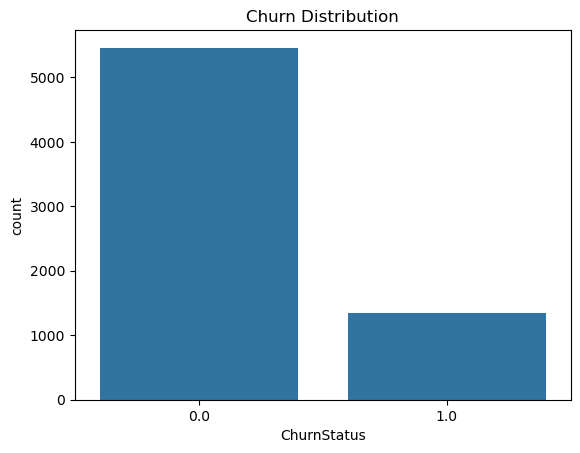

In [19]:
sns.countplot(x="ChurnStatus", data=df)
plt.title("Churn Distribution")
plt.show()

In [20]:

num_cols = [
    "Age",
    "AmountSpent",
    "LoginFrequency"
]

cat_cols = [
    "Gender",
    "MaritalStatus",
    "IncomeLevel",
    "ProductCategory",
    "InteractionType",
    "ResolutionStatus",
    "AgeBracket",
    "ServiceUsage"
]

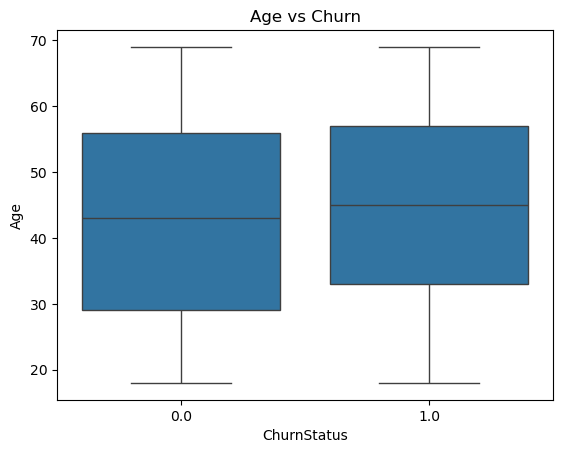

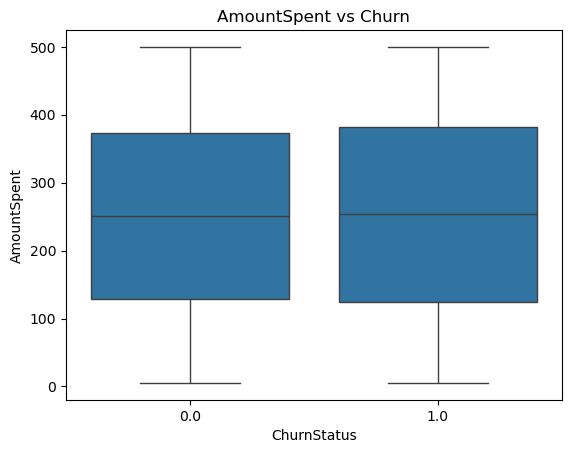

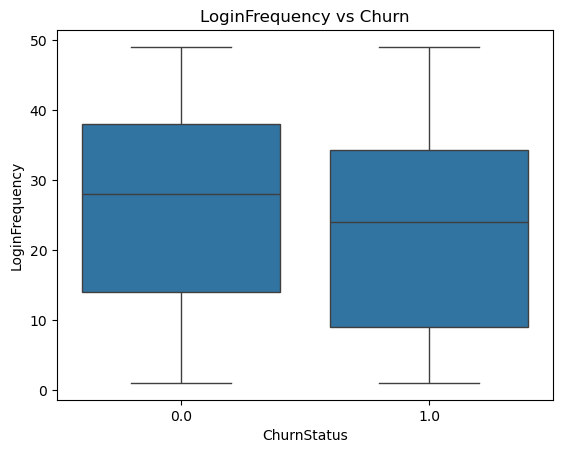

In [21]:
for col in num_cols:
    sns.boxplot(x="ChurnStatus", y=col, data=df)
    plt.title(f"{col} vs Churn")
    plt.show()


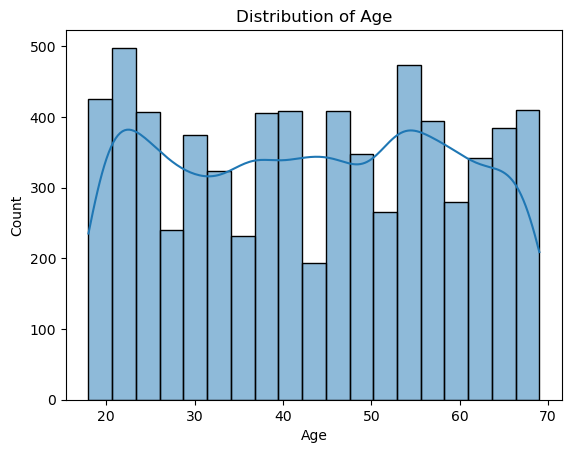

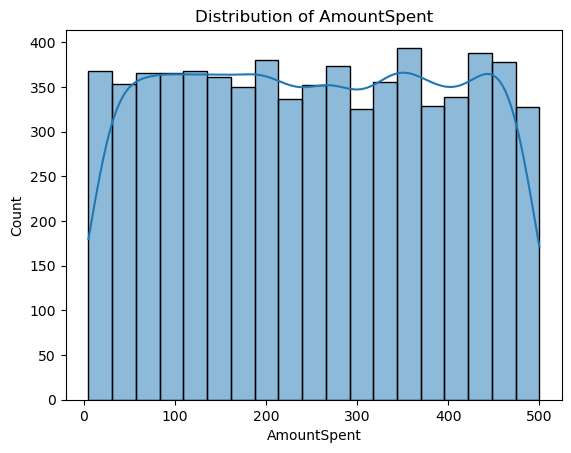

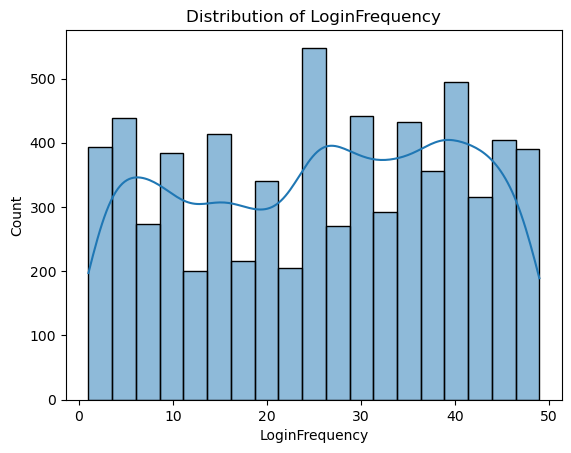

In [22]:
for col in num_cols:
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

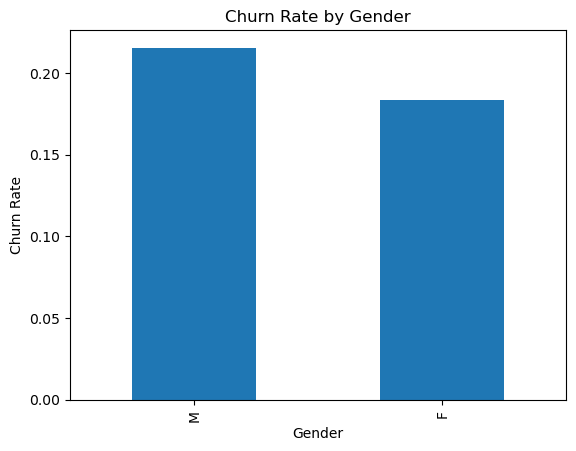

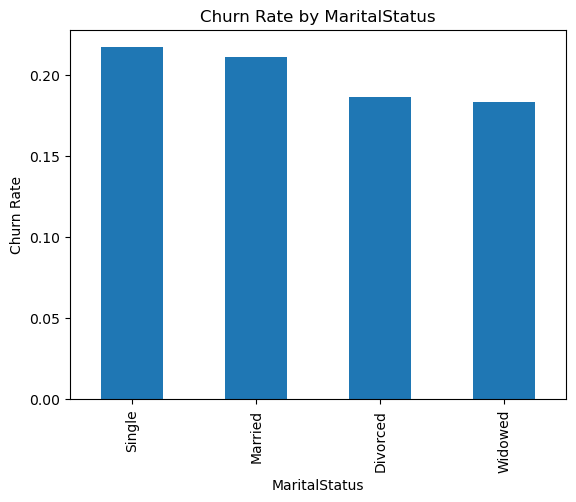

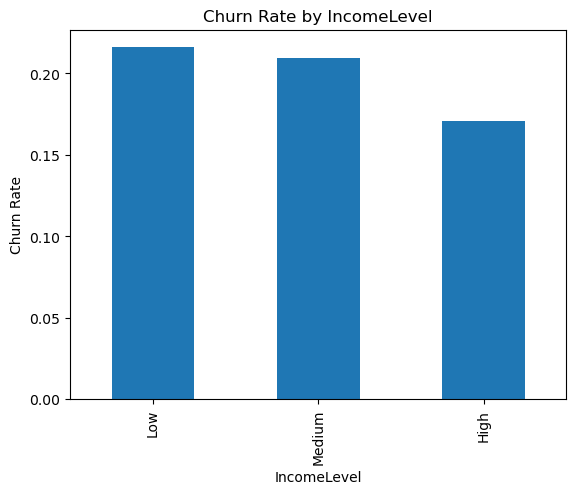

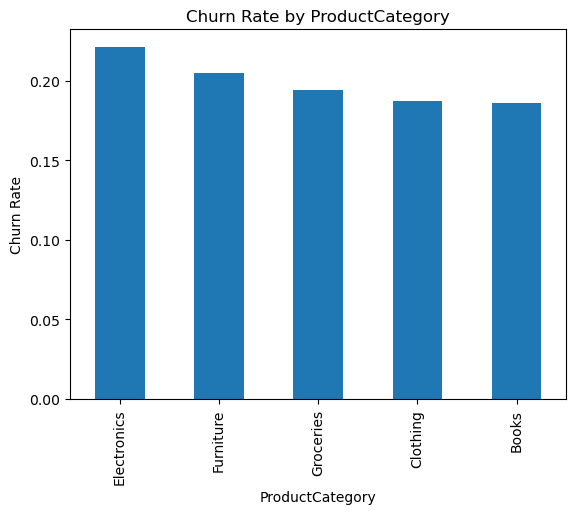

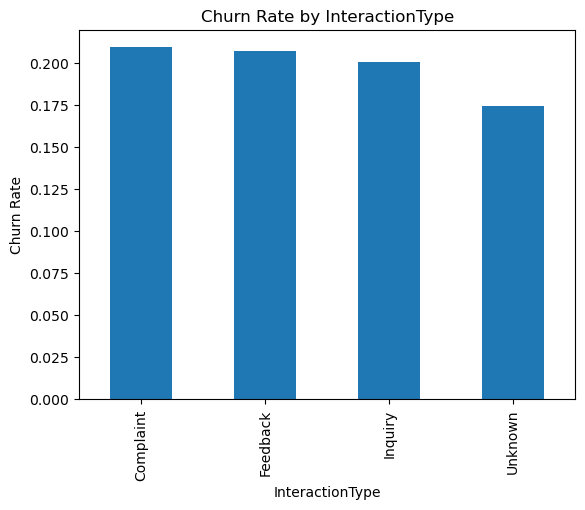

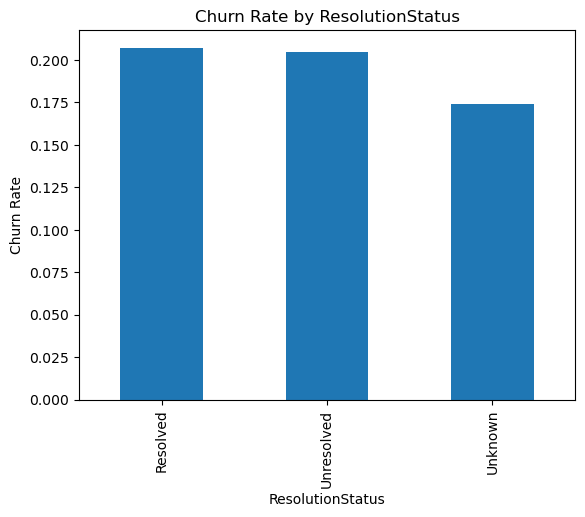

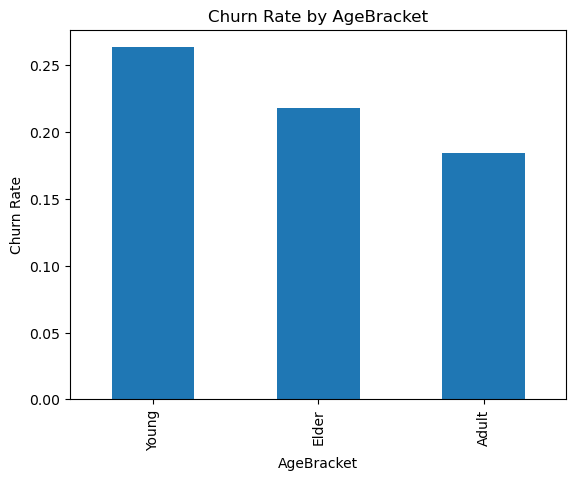

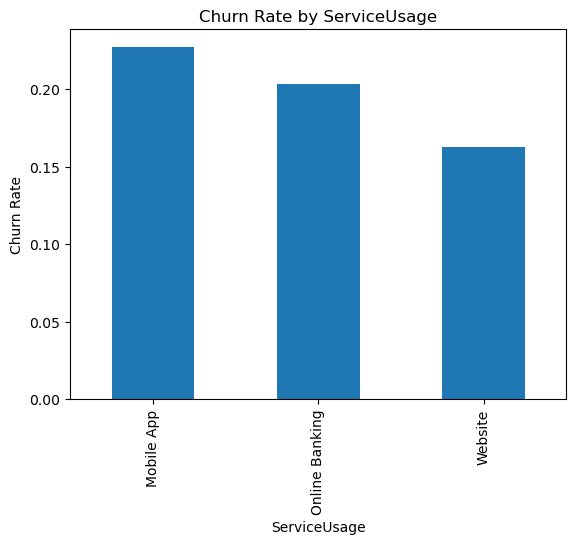

In [23]:
#Plot cat_cols against churn_rate
for col in cat_cols:
    churn_rate = (
        df.groupby(col)["ChurnStatus"]
        .mean()
        .sort_values(ascending=False)
    )
    churn_rate.plot(kind="bar")
    plt.title(f"Churn Rate by {col}")
    plt.ylabel("Churn Rate")
    plt.show()

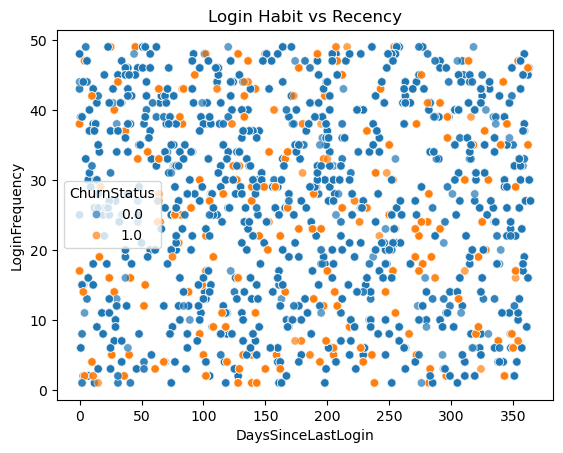

In [24]:
#Plot scatterplot with dayssincelastlogin against loginfrequency, hue=Chrunstatus
sns.scatterplot(
    data=df,
    x="DaysSinceLastLogin",
    y="LoginFrequency",
    hue="ChurnStatus",
    alpha=0.7
)
plt.title("Login Habit vs Recency")
plt.show()

In [25]:
# Load data n define target
X = df.drop("ChurnStatus", axis=1)   # change if needed
y = df["ChurnStatus"]

In [26]:
# Train-test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [27]:
# Identify numerical and categorical features
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X.select_dtypes(include=["object", "category"]).columns


In [28]:
# Build preprocessing pipeline
numeric_transformer = Pipeline(steps=[
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)


In [29]:
# Handle class imbalance, compute imbalance ratio for XGBoost
neg, pos = y.value_counts()
scale_pos_weight = neg / pos


In [30]:
# Define models (with imbalance handling)

from sklearn.svm import SVC
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    ),

    "Random Forest": RandomForestClassifier(
        random_state=42,
        class_weight="balanced"
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    ),

    "SVM": SVC(
        probability=True,
        class_weight="balanced"
    ),

    "XGBoost": XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        scale_pos_weight=scale_pos_weight
    )
}


In [31]:
# Pipeline 
pipelines = {
    name: Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    for name, model in models.items()
}


In [32]:
# Define GridSearch parameters
param_grids = {
    "Logistic Regression": {
        "model__C": [0.01, 0.1, 1, 10]
    },

    "Random Forest": {
        "model__n_estimators": [100, 200],
        "model__max_depth": [None, 10, 20]
    },

    "Gradient Boosting": {
        "model__n_estimators": [100, 200],
        "model__learning_rate": [0.05, 0.1]
    },

    "SVM": {
        "model__C": [0.1, 1],
        "model__kernel": ["rbf"]
    },

    "XGBoost": {
        "model__n_estimators": [100, 200],
        "model__max_depth": [3, 5],
        "model__learning_rate": [0.05, 0.1],
        "model__subsample": [0.8, 1.0]
    }
}


In [33]:
#Train, tune, and compare models
results = {}
best_estimators = {}

for name, pipeline in pipelines.items():
    print(f"Training {name}...")

    grid = GridSearchCV(
        pipeline,
        param_grids[name],
        cv=5,
        scoring="roc_auc",
        n_jobs=-1
    )

    grid.fit(X_train, y_train)

    best_estimators[name] = grid.best_estimator_

    y_prob = grid.best_estimator_.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= 0.5).astype(int)

    results[name] = {
        "ROC_AUC": roc_auc_score(y_test, y_prob),
        "Accuracy": accuracy_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred)
    }


Training Logistic Regression...
Training Random Forest...
Training Gradient Boosting...
Training SVM...
Training XGBoost...


In [34]:
# selecting best model (by ROC-AUC)
results_df = pd.DataFrame(results).T
results_df = results_df.sort_values(by="ROC_AUC", ascending=False)

print(results_df)


                      ROC_AUC  Accuracy        F1
Random Forest        0.998674  0.982392  0.954023
XGBoost              0.995729  0.980924  0.951852
Gradient Boosting    0.939929  0.885547  0.606061
SVM                  0.909868  0.895084  0.715706
Logistic Regression  0.586645  0.570800  0.325260


In [35]:
best_model_name = results_df.index[0]
best_model = best_estimators[best_model_name]

print("Best model:", best_model_name)


Best model: Random Forest


In [37]:
# Select the best Random Forest model from GridSearch
best_rf = best_estimators["Random Forest"]



In [39]:
# Generate Predictions & Probabilities 
# Class predictions (0 or 1)
y_pred = best_rf.predict(X_test)

# Predicted probabilities (needed for ROC & thresholding)
y_proba = best_rf.predict_proba(X_test)[:, 1]


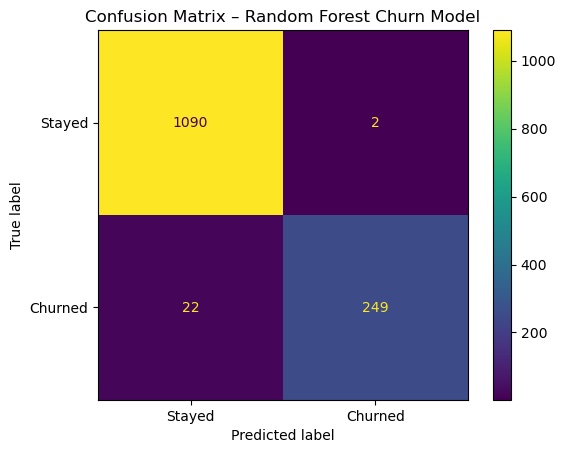

In [40]:

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Stayed", "Churned"]
)

disp.plot()
plt.title("Confusion Matrix – Random Forest Churn Model")
plt.show()

In [41]:
print("Random Forest – Classification Report")
print(classification_report(y_test, y_pred))

Random Forest – Classification Report
              precision    recall  f1-score   support

         0.0       0.98      1.00      0.99      1092
         1.0       0.99      0.92      0.95       271

    accuracy                           0.98      1363
   macro avg       0.99      0.96      0.97      1363
weighted avg       0.98      0.98      0.98      1363



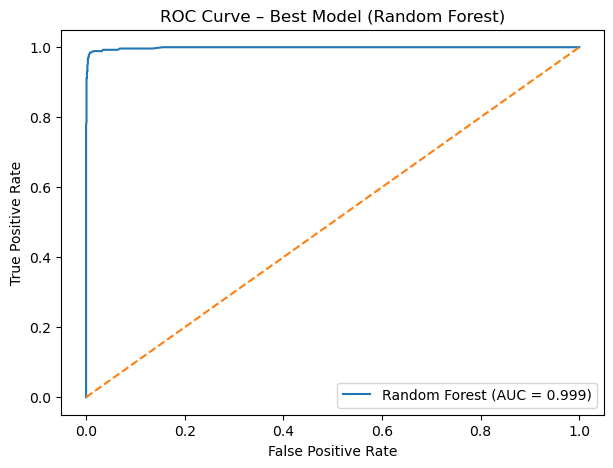

In [42]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f"Random Forest (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Best Model (Random Forest)")
plt.legend()
plt.show()


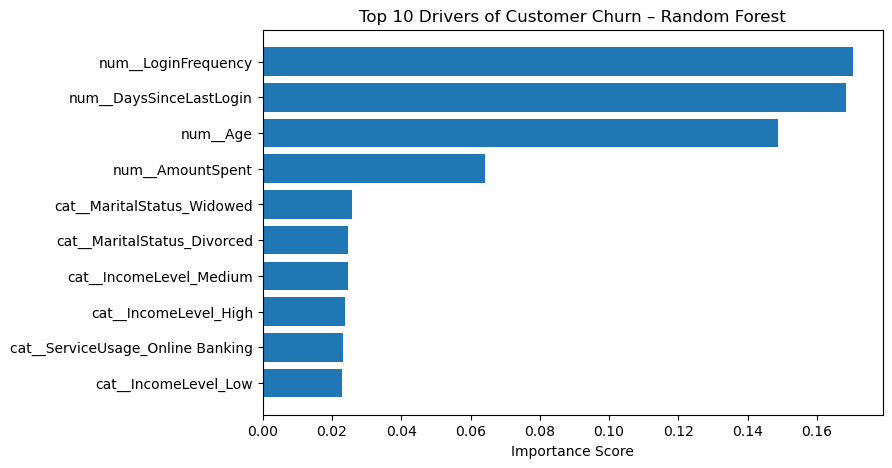

In [43]:
# Extract feature names after preprocessing
feature_names = best_rf.named_steps["preprocessor"].get_feature_names_out()

# Extract feature importance from Random Forest
importances = best_rf.named_steps["model"].feature_importances_

# Create importance dataframe
fi_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

# Plot top 10 features
top10 = fi_df.head(10)

plt.figure(figsize=(8,5))
plt.barh(top10["Feature"], top10["Importance"])
plt.gca().invert_yaxis()
plt.xlabel("Importance Score")
plt.title("Top 10 Drivers of Customer Churn – Random Forest")
plt.show()


In [44]:
# THRESHOLD TUNING using Default threshold = 0.5

thresholds = np.arange(0.1, 0.9, 0.05)
f1_scores = []

for t in thresholds:
    y_thresh_pred = (y_proba >= t).astype(int)
    f1_scores.append(f1_score(y_test, y_thresh_pred))

best_threshold = thresholds[np.argmax(f1_scores)]

print("Optimal Threshold:", best_threshold)
print("Best F1 at Threshold:", max(f1_scores))



Optimal Threshold: 0.30000000000000004
Best F1 at Threshold: 0.9762340036563071
